## Kurulum

In [ ]:
# check assigned GPU, T4 expected
# atanan GPU kontrolu, T4 bekleniyor
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader


In [ ]:
# install rfdetr, pycocotools (test-set mAP), supervision (rfdetr's own
# detection container), openpyxl (Excel logging)
# rfdetr, pycocotools (test-set mAP), supervision (rfdetr'nin kendi
# detection konteyneri), openpyxl (Excel loglama) kurulumu
!pip install -q "rfdetr[train,loggers]" pycocotools supervision openpyxl
import rfdetr
print('rfdetr surumu:', getattr(rfdetr, '__version__', 'bilinmiyor'))


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
from pathlib import Path
import shutil

# same cropped YOLO-format dataset used for YOLO11/YOLO26 -- this notebook
# converts it to COCO format separately (RF-DETR's primary, best-documented
# format) without touching this folder.
# YOLO11/YOLO26 ile ayni kirpilmis YOLO-format veri seti -- bu notebook
# onu ayrica COCO formatina cevirir (RF-DETR'nin birincil, en iyi
# belgelenmis formati), bu klasoru degistirmez.
DATASET_ROOT = '/content/drive/MyDrive/Kitle-Vindr-Cropped'

MODEL_NAME = 'rfdetr_s_cropped'

# Drive is the durable store (checkpoints survive a disconnect, same as the
# YOLO experiments); local disk is a fast mirror of every output.
# Drive kalici depo (checkpoint'ler koparsa kaybolmaz, YOLO denemeleriyle
# ayni); yerel disk her ciktinin hizli bir aynasidir.
DRIVE_DIR = f'/content/drive/MyDrive/mass_detection/{MODEL_NAME}'
LOCAL_DIR = f'/content/outputs/{MODEL_NAME}'
Path(DRIVE_DIR).mkdir(parents=True, exist_ok=True)
Path(LOCAL_DIR).mkdir(parents=True, exist_ok=True)

EXCEL_LOG = f'{DRIVE_DIR}/{MODEL_NAME}_log.xlsx'

# one-time COCO conversion output, shared by any future RF-DETR experiment
# (kept separate from DRIVE_DIR since it's input data, not this run's output)
# bir kereye mahsus COCO donusum ciktisi, ileride baska RF-DETR denemeleri
# de kullanabilir (DRIVE_DIR'dan ayri tutulur, cunku bu bir girdi verisi,
# bu denemenin ciktisi degil)
COCO_ROOT = '/content/drive/MyDrive/Kitle-Vindr-Cropped-COCO'

assert Path(DATASET_ROOT).is_dir(), f'Yol yok: {DATASET_ROOT}'
print('Kaynak veri (YOLO format, kirpilmis):', DATASET_ROOT)
print('COCO donusum ciktisi:', COCO_ROOT)
print('Drive cikti (kalici):', DRIVE_DIR)
print('Yerel cikti (ayna):', LOCAL_DIR)


def mirror_to_local(drive_path):
    # copy a Drive output file to the local mirror, same filename
    # Drive'daki bir cikti dosyasini ayni adla yerel aynaya kopyala
    dst = Path(LOCAL_DIR) / Path(drive_path).name
    shutil.copy2(drive_path, dst)
    return str(dst)


## Veri Donusumu: YOLO -> COCO

RF-DETR'nin en iyi belgelenmis, birincil veri formati COCO (`_annotations.coco.json`).
YOLO-format otomatik-algilama da var ama split klasor adlandirmasinda
(`val` mi `valid` mi) dokumantasyon celisiyordu -- bu belirsizligi tasimamak
icin COCO'ya donusturup kullaniyoruz. Ayrica test seti mAP50/mAP50-95
hesabi icin zaten `pycocotools` gerekecek (asagida, Degerlendirme
bolumunde), o yuzden bu COCO JSON'u orada da tekrar kullanacagiz.

Donusum tek seferlik ve idempotent: `Kitle-Vindr-Cropped-COCO` zaten
dogru goruntu sayisiyla mevcutsa split atlanir.

In [ ]:
import json
from PIL import Image

# RF-DETR / Roboflow COCO export split adlandirmasi: train/valid/test
# RF-DETR / Roboflow COCO export split naming convention: train/valid/test
SPLIT_MAP = {'train': 'train', 'val': 'valid', 'test': 'test'}
CATEGORIES = [{'id': 1, 'name': 'mass', 'supercategory': 'none'}]


def yolo_to_coco_split(src_split, dst_split_name):
    # convert one split's YOLO images+labels into a Roboflow-style COCO folder
    # bir split'in YOLO goruntu+etiketlerini Roboflow-stili COCO klasorune cevir
    src_img_dir = Path(DATASET_ROOT) / src_split / 'images'
    src_lbl_dir = Path(DATASET_ROOT) / src_split / 'labels'
    dst_dir = Path(COCO_ROOT) / dst_split_name
    dst_dir.mkdir(parents=True, exist_ok=True)

    images, annotations = [], []
    ann_id = 1
    img_paths = sorted(src_img_dir.glob('*.png'))
    for img_id, ip in enumerate(img_paths, start=1):
        dst_ip = dst_dir / ip.name
        if not dst_ip.exists():
            shutil.copy2(ip, dst_ip)
        with Image.open(ip) as im:
            w, h = im.size
        images.append({'id': img_id, 'file_name': ip.name, 'width': w, 'height': h})

        lp = src_lbl_dir / f'{ip.stem}.txt'
        if lp.exists():
            for line in open(lp):
                parts = line.split()
                if len(parts) < 5:
                    continue
                cx, cy, bw, bh = [float(x) for x in parts[1:5]]
                # normalized xywh (center) -> COCO xywh (pixel, top-left)
                # normalize xywh (merkez) -> COCO xywh (piksel, sol-ust)
                px_w, px_h = bw * w, bh * h
                px_x, px_y = (cx - bw / 2) * w, (cy - bh / 2) * h
                annotations.append({
                    'id': ann_id, 'image_id': img_id, 'category_id': 1,
                    'bbox': [px_x, px_y, px_w, px_h],
                    'area': px_w * px_h, 'iscrowd': 0,
                })
                ann_id += 1

    n_copied = len(list(dst_dir.glob('*.png')))
    assert n_copied == len(img_paths), (
        f'{src_split}: {len(img_paths)} kaynak goruntu ama {n_copied} kopyalandi '
        '-- Drive kopyalama sirasinda dosya kaybi (daha once yasandi), tekrar dene.'
    )

    coco = {'images': images, 'annotations': annotations, 'categories': CATEGORIES}
    with open(dst_dir / '_annotations.coco.json', 'w') as f:
        json.dump(coco, f)
    return len(images), len(annotations)


# idempotent: skip a split if it already has the right image count
# idempotent: bir split zaten dogru goruntu sayisina sahipse atla
for src_split, dst_split in SPLIT_MAP.items():
    dst_dir = Path(COCO_ROOT) / dst_split
    src_count = len(list((Path(DATASET_ROOT) / src_split / 'images').glob('*.png')))
    existing_count = len(list(dst_dir.glob('*.png'))) if dst_dir.exists() else 0
    ann_file = dst_dir / '_annotations.coco.json'
    if existing_count == src_count and ann_file.exists():
        print(f'{dst_split}: zaten guncel ({existing_count} goruntu), atlandi.')
        continue
    n_img, n_ann = yolo_to_coco_split(src_split, dst_split)
    print(f'{dst_split}: {n_img} goruntu, {n_ann} kutu -> {dst_dir}')

print('\nCOCO donusumu tamam:', COCO_ROOT)


## Kirpilmis Veri EDA

Egitime baslamadan once kirpma sonrasi veriyi dogrula: split basina
goruntu/kutu sayisi ve kucuk nesne orani, sonra birkac ornek goruntu.
Hala orijinal YOLO `.txt` etiketlerinden okunuyor (`Kitle-Vindr-Cropped`),
COCO donusumunden bagimsiz -- YOLO11/YOLO26 notebook'larindaki EDA ile
birebir ayni, dogrudan kiyaslanabilir olmasi icin.

In [ ]:
import numpy as np

def split_stats(split):
    # per-split image/box counts and normalized bbox area ratios
    # split basina goruntu/kutu sayisi ve normalize bbox alan oranlari
    img_dir = Path(DATASET_ROOT) / split / 'images'
    lbl_dir = Path(DATASET_ROOT) / split / 'labels'
    imgs = sorted(img_dir.glob('*.png'))
    n_boxes = 0
    areas = []
    for ip in imgs:
        lp = lbl_dir / f'{ip.stem}.txt'
        if not lp.exists():
            continue
        for line in open(lp):
            parts = line.split()
            if len(parts) >= 5:
                n_boxes += 1
                areas.append(float(parts[3]) * float(parts[4]))
    return len(imgs), n_boxes, areas


print(f"{'Split':6s} {'Goruntu':8s} {'Kutu':6s} {'Kutu/Gor':9s} {'Medyan Alan':12s} {'Alan<%1':8s}")
all_areas = []
for split in ['train', 'val', 'test']:
    n_img, n_box, areas = split_stats(split)
    all_areas += areas
    med = np.median(areas) if areas else 0
    small_ratio = 100 * np.mean(np.array(areas) < 0.01) if areas else 0
    print(f"{split:6s} {n_img:<8d} {n_box:<6d} {n_box/n_img:<9.2f} {med:<12.5f} %{small_ratio:.1f}")

print(f"\nToplam kutu: {len(all_areas)}")
print(f"Genel medyan bbox alan orani: {np.median(all_areas):.5f}")
print(f"Alani goruntunun %1'inden kucuk kutu orani: %{100*np.mean(np.array(all_areas) < 0.01):.1f}")
print("\n(Kutu sayilari kirpma-onisleme notebook'undaki rapor ile ayni olmali: train 3203, val 418, test 400.)")


In [ ]:
import cv2
import matplotlib.pyplot as plt
import random

random.seed(42)
TRAIN_IMG = Path(DATASET_ROOT) / 'train' / 'images'
TRAIN_LBL = Path(DATASET_ROOT) / 'train' / 'labels'


def load_gt_boxes(stem):
    lp = TRAIN_LBL / f'{stem}.txt'
    boxes = []
    if lp.exists():
        for line in open(lp):
            parts = line.split()
            if len(parts) >= 5:
                boxes.append([float(x) for x in parts[1:5]])
    return boxes


labeled = [ip for ip in TRAIN_IMG.glob('*.png') if load_gt_boxes(ip.stem)]
sample = random.sample(labeled, min(6, len(labeled)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, ip in zip(axes.flat, sample):
    img = cv2.imread(str(ip))
    h, w = img.shape[:2]
    for (cx, cy, bw, bh) in load_gt_boxes(ip.stem):
        x1 = int((cx - bw/2) * w); y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w); y2 = int((cy + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 6)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{ip.name} ({w}x{h})', fontsize=9)
    ax.axis('off')
plt.suptitle('Kirpilmis Egitim Ornekleri', fontsize=14)
plt.tight_layout()

sample_path = f'{DRIVE_DIR}/{MODEL_NAME}_train_samples.png'
plt.savefig(sample_path, dpi=150, bbox_inches='tight')
mirror_to_local(sample_path)
plt.show()
print('Ornek goruntuler kaydedildi (Drive + yerel):', sample_path)


## Model ve Egitim Parametreleri

**RFDETRSmall**: YOLO11s/YOLO26s ile ("s" boyut) parite icin, adil 3'lu
kiyaslama amaciyla secildi.

**`batch_size`/`grad_accum_steps`**: Resmi RF-DETR dokumantasyonu T4 icin
efektif batch 16'ya ulasmak amaciyla `batch_size=4, grad_accum_steps=4`
ornegini kullaniyor -- buradan basliyoruz; OOM olursa `batch_size` dusurulup
`grad_accum_steps` artirilarak telafi edilecek (Colab'da doğrulanacak nokta).

**`early_stopping_patience=5`**: Bu projede YOLO11/YOLO26 denemelerinde
(Deney 2a-2f) dogrulanmis ayni erken durdurma kurali, uc modelde tutarlilik
icin korunuyor.

In [ ]:
MODEL_CFG = dict(
    epochs=100,
    batch_size=4,
    grad_accum_steps=4,
    lr=1e-4,
    early_stopping=True,
    early_stopping_patience=5,
    seed=42,
)
print(MODEL_CFG)


## Egitim Altyapisi

Standart metrik semasi (`SCHEMA`) ve egitim egrisi fonksiyonu, YOLO11/YOLO26
notebook'larindakiyle birebir ayni -- adil karsilastirma icin. RF-DETR
Ultralytics'in `on_fit_epoch_end` callback sistemini kullanmadigindan (ve
guncel surumde tam callback imzasi guvenilir sekilde belgeli olmadigindan),
canli bir callback'e guvenmek yerine RF-DETR'nin kendi her zaman urettigi
`metrics.csv` dosyasini egitim sonrasi okuyup standart semaya ceviriyoruz.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# standard metric schema, identical for all three models
# standart metrik semasi, uc model icin ayni
SCHEMA = ["epoch", "train_loss", "val_loss", "precision", "recall", "mAP50", "mAP50_95", "f1"]


def compute_f1(precision, recall):
    # F1 from precision and recall, safe against zero division
    # precision ve recall'dan F1, sifira bolmeye karsi guvenli
    if precision is None or recall is None:
        return None
    denom = precision + recall
    if denom <= 0:
        return 0.0
    return 2 * precision * recall / denom


def append_epoch_row(excel_path, row, resume_epoch=None):
    if os.path.exists(excel_path):
        df = pd.read_excel(excel_path)
        if resume_epoch is not None:
            df = df[df["epoch"] < resume_epoch]
        rows = df.to_dict("records")
    else:
        rows = []
    clean = {k: row.get(k, None) for k in SCHEMA}
    rows.append(clean)
    pd.DataFrame(rows)[SCHEMA].to_excel(excel_path, index=False)
    return len(rows)


def plot_training_curves(excel_path, out_path, model_name):
    # draw the 4 required curves: loss, mAP, precision, recall
    # istenen 4 egriyi ciz: loss, mAP, precision, recall
    df = pd.read_excel(excel_path)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    ax.plot(df["epoch"], df["train_loss"], marker="o", markersize=3, label="Train")
    if df["val_loss"].notna().any():
        ax.plot(df["epoch"], df["val_loss"], marker="o", markersize=3, label="Val")
    ax.set_title("Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.plot(df["epoch"], df["mAP50"], marker="o", markersize=3, label="mAP@50")
    ax.plot(df["epoch"], df["mAP50_95"], marker="o", markersize=3, label="mAP@50-95")
    ax.set_title("mAP"); ax.set_xlabel("Epoch"); ax.set_ylabel("mAP")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    ax.plot(df["epoch"], df["precision"], marker="o", markersize=3, color="tab:green", label="Precision")
    ax.set_title("Precision"); ax.set_xlabel("Epoch"); ax.set_ylabel("Precision")
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    ax.plot(df["epoch"], df["recall"], marker="o", markersize=3, color="tab:red", label="Recall")
    ax.set_title("Recall"); ax.set_xlabel("Epoch"); ax.set_ylabel("Recall")
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.suptitle(f"{model_name} Egitim Egrileri", fontsize=14)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    return out_path

print("Ortak modul hazir.")


In [ ]:
def diagnose_metrics_csv(csv_path):
    # print actual column names before mapping to SCHEMA -- RF-DETR's
    # metrics.csv column names aren't reliably documented, verify instead
    # of guessing (same "diagnose before assuming" principle used for
    # YOLO26's Grad-CAM architecture debugging).
    # metrics.csv'nin gercek kolon adlarini SCHEMA'ya eslemeden once
    # yazdir -- RF-DETR'nin kolon adlari guvenilir sekilde belgeli degil,
    # tahmin etmek yerine dogrula (YOLO26 Grad-CAM mimarisi hata
    # ayiklamasinda kullanilan ayni "once teshis et" ilkesi).
    df = pd.read_csv(csv_path)
    print('metrics.csv kolonlari:', list(df.columns))
    print(df.tail())
    return df


def metrics_csv_to_excel(csv_path, excel_path, column_map):
    # column_map: dict mapping SCHEMA keys -> actual metrics.csv column
    # names, confirmed from diagnose_metrics_csv()'s printed output.
    # column_map: SCHEMA anahtarlarini metrics.csv'nin gercek kolon
    # adlarina esleyen sozluk, diagnose_metrics_csv() ciktisindan teyit
    # edildi.
    #
    # RF-DETR (PyTorch Lightning) logs train and val metrics on separate,
    # sparse rows within the same epoch (each row is a single logged step,
    # most columns NaN) -- collapse to one row per epoch by taking the
    # last non-null value of each column within that epoch's rows.
    # RF-DETR (PyTorch Lightning) train ve val metriklerini ayni epoch
    # icinde farkli, seyrek satirlara loglar (her satir tek bir loglanan
    # adim, cogu kolon NaN) -- her epoch'un satirlarindaki son bos-olmayan
    # degeri alarak epoch basina tek satira indirger.
    df = pd.read_csv(csv_path)
    epoch_col = column_map['epoch']
    value_cols = [c for c in column_map.values() if c != epoch_col and c in df.columns]
    grouped = df.groupby(epoch_col)[value_cols].agg(
        lambda s: s.dropna().iloc[-1] if s.notna().any() else None
    ).reset_index()

    rows = []
    for _, r in grouped.iterrows():
        p = r.get(column_map.get('precision'))
        rec = r.get(column_map.get('recall'))
        rows.append({
            'epoch': r.get(epoch_col),
            'train_loss': r.get(column_map.get('train_loss')),
            'val_loss': r.get(column_map.get('val_loss')),
            'precision': p,
            'recall': rec,
            'mAP50': r.get(column_map.get('mAP50')),
            'mAP50_95': r.get(column_map.get('mAP50_95')),
            'f1': compute_f1(p, rec),
        })
    pd.DataFrame(rows)[SCHEMA].to_excel(excel_path, index=False)
    return excel_path

print('Excel donusturucu hazir (COLUMN_MAP, egitim sonrasi kolonlar teshis edildikten sonra doldurulacak).')


## Egitim

In [ ]:
from rfdetr import RFDETRSmall

# resume control: set True only if a run was interrupted and you want to continue
# resume kontrolu: sadece egitim kesildiyse ve devam etmek istiyorsan True yap
RESUME = False

RUN_DIR = Path(f'{DRIVE_DIR}/{MODEL_NAME}_mass')
LAST_CKPT = RUN_DIR / 'checkpoint.pth'

if not RESUME and Path(EXCEL_LOG).exists():
    # fresh start guard: if this MODEL_NAME was used for a previous
    # (possibly failed/aborted) run, a stale Excel log would otherwise get
    # confused with the new run's epochs -- same corrupted-curves bug fixed
    # in the YOLO11/YOLO26 notebooks.
    # taze baslangic guvenligi: bu MODEL_NAME daha once (belki
    # basarisiz/yarim kalmis) bir run icin kullanildiysa, eski Excel logu
    # yeni run'in epoch'lariyla karisir -- YOLO11/YOLO26 notebook'larinda
    # duzeltilen ayni bozuk-grafik hatasi.
    Path(EXCEL_LOG).unlink()
    print(f'Eski log silindi: {EXCEL_LOG}')

if RESUME:
    assert LAST_CKPT.exists(), f'Resume icin checkpoint bulunamadi: {LAST_CKPT}'
    model = RFDETRSmall(pretrain_weights=str(LAST_CKPT))
else:
    model = RFDETRSmall()

model.train(
    dataset_dir=COCO_ROOT,
    output_dir=str(RUN_DIR),
    resume=str(LAST_CKPT) if RESUME else None,
    **MODEL_CFG,
)

print('Egitim bitti.')

# metrics.csv is RF-DETR's own log -- diagnose columns once here, then the
# next cell converts it to the standard Excel schema shared across models.
# metrics.csv RF-DETR'nin kendi logu -- once burada kolonlari teshis et,
# sonraki hucre uc modelde ortak standart Excel semasina cevirir.
METRICS_CSV = RUN_DIR / 'metrics.csv'
assert METRICS_CSV.exists(), f'metrics.csv bulunamadi: {METRICS_CSV}'
_ = diagnose_metrics_csv(METRICS_CSV)

# mirror the full run folder to local disk too
# tum run klasorunu yerele de aynala
run_local_dir = Path(LOCAL_DIR) / RUN_DIR.name
if run_local_dir.exists():
    shutil.rmtree(run_local_dir)
shutil.copytree(RUN_DIR, run_local_dir)
print('Yerel aynaya kopyalandi:', run_local_dir)


In [13]:
# oturum yeniden basladiysa ve egitim hucresini (bir onceki) tekrar
# calistirmadiysaniz -- egitim zaten tamamlanmisti -- RUN_DIR/METRICS_CSV
# burada Drive'daki mevcut ciktidan yeniden kurulur, egitimi tekrarlamadan.
# if the session restarted and you did NOT re-run the training cell above
# (training already finished) -- RUN_DIR/METRICS_CSV are reconstructed
# here from the existing Drive output, without retraining.
#
# RUN_DIR alone isn't a reliable signal: an interrupted re-run of the
# training cell sets RUN_DIR before model.train() but never reaches the
# METRICS_CSV assignment after it -- so check both independently.
# sadece RUN_DIR guvenilir bir isaret degil: egitim hucresinin kesintiye
# ugrayan bir tekrar calistirilmasi RUN_DIR'i model.train()'den once set
# eder ama sonrasindaki METRICS_CSV atamasina hic ulasmaz -- ikisini de
# ayri ayri kontrol et.
if 'RUN_DIR' not in dir():
    RUN_DIR = Path(f'{DRIVE_DIR}/{MODEL_NAME}_mass')
    print('RUN_DIR yeniden kuruldu:', RUN_DIR)
else:
    print('RUN_DIR zaten tanimli, oturumda kaldi:', RUN_DIR)

if 'METRICS_CSV' not in dir():
    METRICS_CSV = RUN_DIR / 'metrics.csv'
    assert METRICS_CSV.exists(), (
        f'metrics.csv bulunamadi: {METRICS_CSV} -- egitim hic calismamis '
        'olabilir, bir onceki (Egitim) hucresini calistirin.'
    )
    print('METRICS_CSV onceki egitimden geri yuklendi:', METRICS_CSV)
else:
    print('METRICS_CSV zaten tanimli, oturumda kaldi:', METRICS_CSV)


RUN_DIR zaten tanimli, oturumda kaldi: /content/drive/MyDrive/mass_detection/rfdetr_s_cropped/rfdetr_s_cropped_mass
METRICS_CSV onceki egitimden geri yuklendi: /content/drive/MyDrive/mass_detection/rfdetr_s_cropped/rfdetr_s_cropped_mass/metrics.csv


In [14]:
# gercek kolon adlari, cell-16'nin ciktisinda yazdirilan metrics.csv'den
# teyit edildi (actual column names, confirmed from cell-16's printed
# metrics.csv output). val/mAP_50 ve val/mAP_50_95 -- EMA olmayan (regular)
# versiyonlar, YOLO11/YOLO26 egrileriyle tutarli kalsin diye; en iyi
# checkpoint secimi (checkpoint_best_total.pth) RF-DETR'nin kendi ic
# mantiginda EMA mAP'i de goz onunde bulunduruyor, bu sadece egri cizimini
# etkiler.
COLUMN_MAP = {
    'epoch': 'epoch',
    'train_loss': 'train/loss',
    'val_loss': 'val/loss',
    'precision': 'val/precision',
    'recall': 'val/recall',
    'mAP50': 'val/mAP_50',
    'mAP50_95': 'val/mAP_50_95',
}
metrics_csv_to_excel(METRICS_CSV, EXCEL_LOG, COLUMN_MAP)
mirror_to_local(EXCEL_LOG)
print('Excel logu yazildi:', EXCEL_LOG)


Excel logu yazildi: /content/drive/MyDrive/mass_detection/rfdetr_s_cropped/rfdetr_s_cropped_log.xlsx


## Degerlendirme

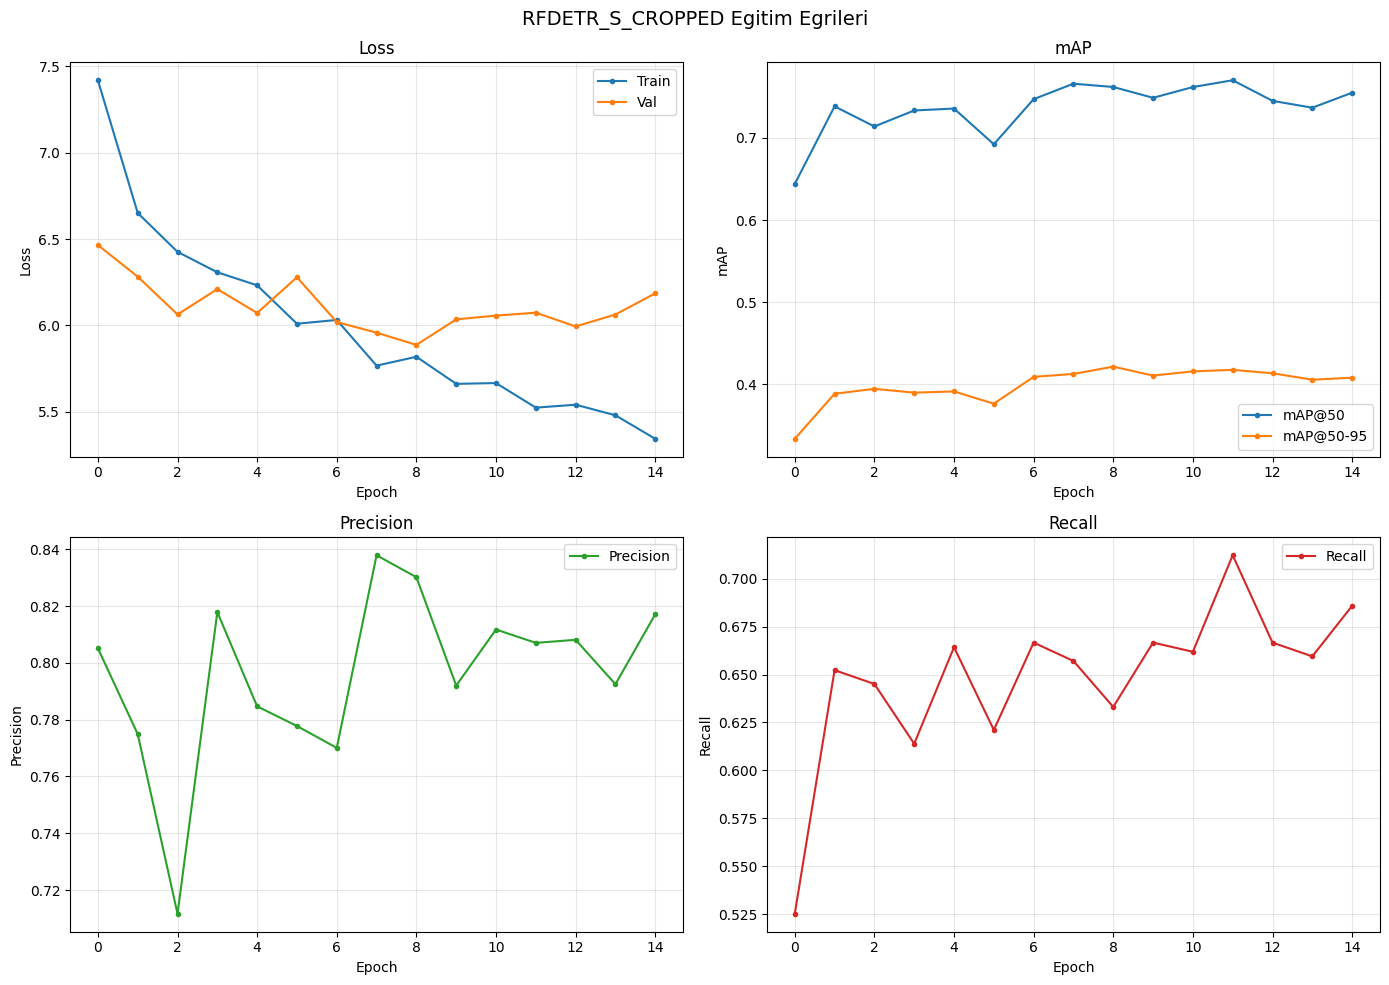

Egitim egrileri kaydedildi (Drive + yerel): /content/drive/MyDrive/mass_detection/rfdetr_s_cropped/rfdetr_s_cropped_curves.png


In [15]:
# draw the standard 4 curves from the converted Excel log
# donusturulmus Excel logundan standart 4 egriyi ciz
curves_path = f'{DRIVE_DIR}/{MODEL_NAME}_curves.png'
plot_training_curves(EXCEL_LOG, curves_path, MODEL_NAME.upper())
mirror_to_local(curves_path)
print('Egitim egrileri kaydedildi (Drive + yerel):', curves_path)


### Test tahminleri

Test setinin tamami uzerinde bir kez tahmin uretip cache'liyoruz; hem
confusion matrix hem de mAP hesabi bu tek tahmin turunu tekrar kullanir.

In [17]:
import json
import supervision as sv
from PIL import Image as PILImage
from collections import defaultdict

BEST_CKPT = RUN_DIR / 'checkpoint_best_total.pth'
test_model = RFDETRSmall(pretrain_weights=str(BEST_CKPT))
test_model.optimize_for_inference()

TEST_COCO_DIR = Path(COCO_ROOT) / 'test'
with open(TEST_COCO_DIR / '_annotations.coco.json') as f:
    test_coco = json.load(f)

IMG_ID_BY_NAME = {im['file_name']: im['id'] for im in test_coco['images']}
IMG_WH_BY_ID = {im['id']: (im['width'], im['height']) for im in test_coco['images']}
ANNS_BY_IMG = defaultdict(list)
for ann in test_coco['annotations']:
    ANNS_BY_IMG[ann['image_id']].append(ann)

CONF_THR = 0.25

test_predictions = {}   # image_id -> supervision.Detections
for fname, img_id in IMG_ID_BY_NAME.items():
    image = PILImage.open(TEST_COCO_DIR / fname)
    test_predictions[img_id] = test_model.predict(image, threshold=CONF_THR)

print(f'{len(test_predictions)} test goruntusu icin tahmin uretildi.')


[2026-07-21 06:33:27] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-21 06:33:27] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-21 06:33:28] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 90. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.
[2026-07-21 06:33:28] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


336 test goruntusu icin tahmin uretildi.


### mAP50 / mAP50-95 (pycocotools)

RF-DETR'nin dogrulanmamis bir ic `.val()`/degerlendirme API'sine guvenmek
yerine, standart `pycocotools.COCOeval` ile test split'inin kendi
`_annotations.coco.json`'una karsi hesapliyoruz -- ayni kutuphane,
YOLO11/YOLO26'nin Ultralytics `.val()` cagrisinin ic mekanizmasinda da
kullanilir, dolayisiyla uc model arasinda mAP tanimi tutarli kalir.

In [18]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

coco_gt = COCO(str(TEST_COCO_DIR / '_annotations.coco.json'))

coco_results = []
for img_id, det in test_predictions.items():
    for (x1, y1, x2, y2), conf in zip(det.xyxy, det.confidence):
        coco_results.append({
            'image_id': int(img_id),
            'category_id': 1,
            'bbox': [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
            'score': float(conf),
        })

coco_dt = coco_gt.loadRes(coco_results)
coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

map50_95 = float(coco_eval.stats[0])   # AP @ IoU=0.50:0.95
map50 = float(coco_eval.stats[1])      # AP @ IoU=0.50
print(f'\nmAP@50    : {map50:.4f}')
print(f'mAP@50-95 : {map50_95:.4f}')


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.09s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.411
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.755
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.408
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.273
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.432
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.429
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.506
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

TP=326  FP=203  FN=74


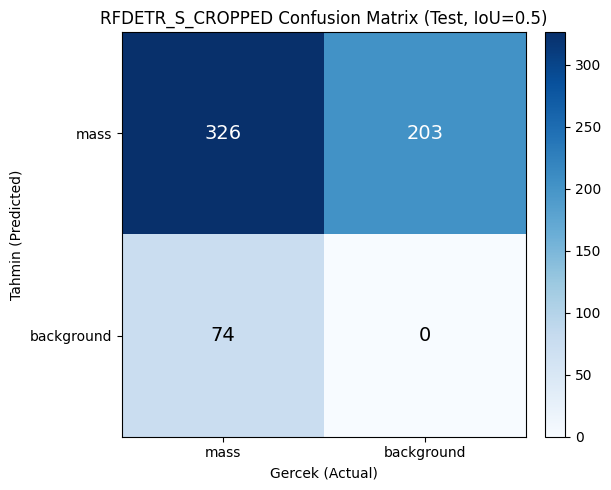

Precision=0.616  Recall=0.815  F1=0.702
Kaydedildi (Drive + yerel): /content/drive/MyDrive/mass_detection/rfdetr_s_cropped/rfdetr_s_cropped_confusion_matrix.png


In [19]:
import numpy as np

# same greedy IoU-matching confusion matrix logic as YOLO11/YOLO26, applied
# to the cached RF-DETR predictions
# YOLO11/YOLO26 ile ayni greedy IoU-eslestirme confusion matrix mantigi,
# cache'lenmis RF-DETR tahminlerine uygulanir


def to_xywhn(det, w, h):
    boxes = []
    for x1, y1, x2, y2 in det.xyxy:
        cx = (x1 + x2) / 2 / w
        cy = (y1 + y2) / 2 / h
        bw = (x2 - x1) / w
        bh = (y2 - y1) / h
        boxes.append([cx, cy, bw, bh])
    return boxes


def load_gt_xywhn(img_id):
    w, h = IMG_WH_BY_ID[img_id]
    boxes = []
    for ann in ANNS_BY_IMG[img_id]:
        x, y, bw, bh = ann['bbox']
        boxes.append([(x + bw / 2) / w, (y + bh / 2) / h, bw / w, bh / h])
    return boxes


def iou_xywh(b1, b2):
    def corners(b):
        x, y, w, h = b
        return [x-w/2, y-h/2, x+w/2, y+h/2]
    a, b = corners(b1), corners(b2)
    inter = max(0, min(a[2], b[2])-max(a[0], b[0])) * max(0, min(a[3], b[3])-max(a[1], b[1]))
    ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter/ua if ua > 0 else 0


TP = FP = FN = 0
IOU_THR = 0.5

for img_id, det in test_predictions.items():
    w, h = IMG_WH_BY_ID[img_id]
    preds = to_xywhn(det, w, h)
    gts = load_gt_xywhn(img_id)

    matched = set()
    for pb in preds:
        best, bj = 0, -1
        for j, gb in enumerate(gts):
            if j in matched:
                continue
            i = iou_xywh(pb, gb)
            if i > best:
                best, bj = i, j
        if best >= IOU_THR:
            TP += 1
            matched.add(bj)
        else:
            FP += 1
    FN += len(gts) - len(matched)

print(f'TP={TP}  FP={FP}  FN={FN}')

cm = np.array([[TP, FP],
               [FN, 0]])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

labels = ['mass', 'background']
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Gercek (Actual)')
ax.set_ylabel('Tahmin (Predicted)')
ax.set_title(f'{MODEL_NAME.upper()} Confusion Matrix (Test, IoU={IOU_THR})')

for i in range(2):
    for j in range(2):
        val = cm[i, j]
        color = 'white' if val > cm.max()/2 else 'black'
        ax.text(j, i, str(val), ha='center', va='center', color=color, fontsize=14)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
cm_path = f'{DRIVE_DIR}/{MODEL_NAME}_confusion_matrix.png'
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
mirror_to_local(cm_path)
plt.show()

precision = TP/(TP+FP) if (TP+FP) > 0 else 0
recall = TP/(TP+FN) if (TP+FN) > 0 else 0
f1 = compute_f1(precision, recall)
print(f'Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}')
print('Kaydedildi (Drive + yerel):', cm_path)


In [20]:
# combine mAP (pycocotools) with precision/recall/F1 (IoU matching) into
# the same test-summary schema used by YOLO11/YOLO26, for direct comparison
# mAP'i (pycocotools) precision/recall/F1 (IoU eslestirme) ile birlestirip
# YOLO11/YOLO26'nin kullandigi ayni test-ozeti semasina yaz, dogrudan
# kiyaslanabilir olmasi icin
summary = pd.DataFrame([{
    'model': MODEL_NAME,
    'mAP50': map50, 'mAP50_95': map50_95,
    'precision': precision, 'recall': recall, 'f1': f1,
}])
summary_path = f'{DRIVE_DIR}/{MODEL_NAME}_test_summary.xlsx'
summary.to_excel(summary_path, index=False)
mirror_to_local(summary_path)

print('TEST SONUCLARI ({})'.format(MODEL_NAME))
print(f'mAP@50    : {map50:.4f}')
print(f'mAP@50-95 : {map50_95:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-Score  : {f1:.4f}')
print('\nTest ozeti kaydedildi (Drive + yerel):', summary_path)


TEST SONUCLARI (rfdetr_s_cropped)
mAP@50    : 0.7551
mAP@50-95 : 0.4109
Precision : 0.6163
Recall    : 0.8150
F1-Score  : 0.7018

Test ozeti kaydedildi (Drive + yerel): /content/drive/MyDrive/mass_detection/rfdetr_s_cropped/rfdetr_s_cropped_test_summary.xlsx


### Grad-CAM -- kapsam disi

RF-DETR, YOLO11/YOLO26'nin aksine bir CNN-detection-head mimarisi degil;
transformer/DINOv2 tabanli bir omurga kullaniyor ve resmi dokumantasyonda
hicbir Grad-CAM/explainability destegi yok. `PROJE_DOKUMANI.md`'nin kendi
notu geregi ("RF-DETR'ye gecilince... korukorune kopyalamadan once mimariyi
teshis et"), YOLO tarafindaki hook-tabanli Grad-CAM kodu buraya
tasinmiyor. Bu, egitim sonuclari elde edildikten sonra ayri bir adim
olarak (once `type(model)`/`print(model)` ile mimari teshis edilerek)
ele alinacak.